In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import torch
import numpy as np

from dataset.dataset import Dataset
from utils.config import load_config
from utils.builder import build_trainer

# ResNet trained on male cohort

In [2]:
config_path = "../configs/resnet_m.yaml"

In [3]:
config = load_config(config_path)
data_path = "../"+config["data"]["data_path"]

torch.manual_seed(config["experiment"]["seed"])
np.random.seed(config["experiment"]["seed"])

dataset = Dataset(data_path, "G", config["data"]["batch_size"], use_tabular=config["data"]["use_tabular"], tabular_features=config["data"]["tabular_features"])
train_loader, val_loader, test_loader = dataset.get_loaders()

dataset_f = Dataset(data_path, "F", config["data"]["batch_size"])
_, val_loader_f, test_loader_f = dataset_f.get_loaders()

dataset_m = Dataset(data_path, "M", config["data"]["batch_size"])       
_, val_loader_m, test_loader_m = dataset_m.get_loaders()

In [4]:
trainer = build_trainer(config)
trainer.load_checkpoint()

## Testing with simillar threshold

In [5]:
best_thr = trainer.choose_threshold(val_loader)

/home/maryna/anaconda3/envs/compmed/lib/python3.9/site-packages/torch/nn/modules/conv.py:366: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1027.)
  return F.conv1d(


Best threshold: 0.276
Sensitivity: 0.915
Specificity: 0.840
AUC: 0.949
Accuracy: 0.877


In [6]:
print("\n===== ALL =====")
out = trainer.test(test_loader, best_thr)


===== ALL =====
           TEST RESULTS
  Threshold         : 0.276
  AUC               : 0.9489
  Accuracy          : 0.8691
  Sensitivity       : 0.9332  (recall on MI)
  Specificity       : 0.7983  (recall on NORM)
  Precision         : 0.8363
  F1 Score          : 0.8821
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     574        145
  True MI    :      53        741
              precision    recall  f1-score   support

        NORM       0.92      0.80      0.85       719
          MI       0.84      0.93      0.88       794

    accuracy                           0.87      1513
   macro avg       0.88      0.87      0.87      1513
weighted avg       0.87      0.87      0.87      1513



In [7]:
print("\n===== FEMALE =====")
out = trainer.test(test_loader_f, best_thr)


===== FEMALE =====
           TEST RESULTS
  Threshold         : 0.276
  AUC               : 0.9370
  Accuracy          : 0.8429
  Sensitivity       : 0.8844  (recall on MI)
  Specificity       : 0.8023  (recall on NORM)
  Precision         : 0.8138
  F1 Score          : 0.8476
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     284         70
  True MI    :      40        306
              precision    recall  f1-score   support

        NORM       0.88      0.80      0.84       354
          MI       0.81      0.88      0.85       346

    accuracy                           0.84       700
   macro avg       0.85      0.84      0.84       700
weighted avg       0.85      0.84      0.84       700



In [8]:
print("\n===== MALE =====")
out = trainer.test(test_loader_m, best_thr)


===== MALE =====
           TEST RESULTS
  Threshold         : 0.276
  AUC               : 0.9736
  Accuracy          : 0.8831
  Sensitivity       : 0.9681  (recall on MI)
  Specificity       : 0.7975  (recall on NORM)
  Precision         : 0.8281
  F1 Score          : 0.8927
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     323         82
  True MI    :      13        395
              precision    recall  f1-score   support

        NORM       0.96      0.80      0.87       405
          MI       0.83      0.97      0.89       408

    accuracy                           0.88       813
   macro avg       0.89      0.88      0.88       813
weighted avg       0.89      0.88      0.88       813



## Choosing best threshold separately for G, M and F

In [9]:
best_thr = trainer.choose_threshold(val_loader)

print("\n===== ALL =====")
out = trainer.test(test_loader, best_thr)

Best threshold: 0.368
Sensitivity: 0.909
Specificity: 0.871
AUC: 0.957
Accuracy: 0.889

===== ALL =====
           TEST RESULTS
  Threshold         : 0.368
  AUC               : 0.9473
  Accuracy          : 0.8757
  Sensitivity       : 0.8928  (recall on MI)
  Specificity       : 0.8595  (recall on NORM)
  Precision         : 0.8579
  F1 Score          : 0.8750
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     667        109
  True MI    :      79        658
              precision    recall  f1-score   support

        NORM       0.89      0.86      0.88       776
          MI       0.86      0.89      0.88       737

    accuracy                           0.88      1513
   macro avg       0.88      0.88      0.88      1513
weighted avg       0.88      0.88      0.88      1513



In [10]:
best_thr = trainer.choose_threshold(val_loader_f)

print("\n===== FEMALE =====")
out = trainer.test(test_loader_f, best_thr)

Best threshold: 0.285
Sensitivity: 0.900
Specificity: 0.816
AUC: 0.945
Accuracy: 0.853

===== FEMALE =====
           TEST RESULTS
  Threshold         : 0.285
  AUC               : 0.9196
  Accuracy          : 0.8386
  Sensitivity       : 0.8761  (recall on MI)
  Specificity       : 0.8033  (recall on NORM)
  Precision         : 0.8071
  F1 Score          : 0.8402
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     290         71
  True MI    :      42        297
              precision    recall  f1-score   support

        NORM       0.87      0.80      0.84       361
          MI       0.81      0.88      0.84       339

    accuracy                           0.84       700
   macro avg       0.84      0.84      0.84       700
weighted avg       0.84      0.84      0.84       700



In [11]:
best_thr = trainer.choose_threshold(val_loader_m)

print("\n===== MALE =====")
out = trainer.test(test_loader_m, best_thr)

Best threshold: 0.281
Sensitivity: 0.928
Specificity: 0.836
AUC: 0.956
Accuracy: 0.881

===== MALE =====
           TEST RESULTS
  Threshold         : 0.281
  AUC               : 0.9626
  Accuracy          : 0.8905
  Sensitivity       : 0.9490  (recall on MI)
  Specificity       : 0.8304  (recall on NORM)
  Precision         : 0.8519
  F1 Score          : 0.8978
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     333         68
  True MI    :      21        391
              precision    recall  f1-score   support

        NORM       0.94      0.83      0.88       401
          MI       0.85      0.95      0.90       412

    accuracy                           0.89       813
   macro avg       0.90      0.89      0.89       813
weighted avg       0.90      0.89      0.89       813



### ROC curves

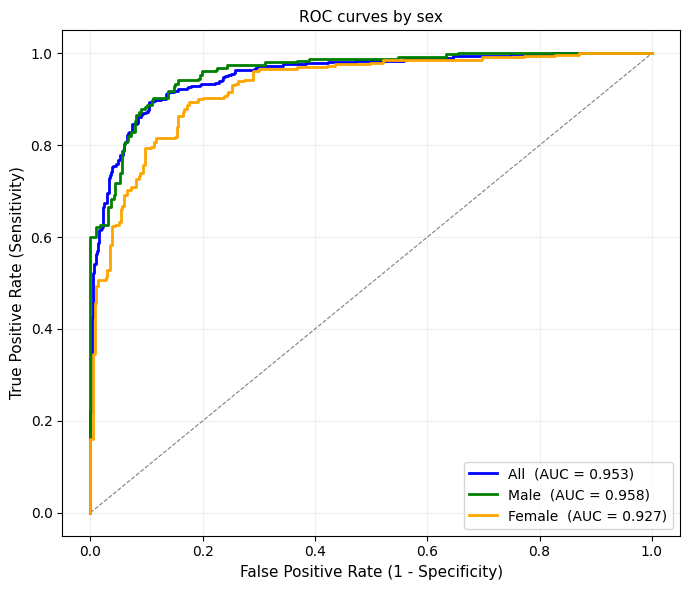

In [12]:
from utils.metrics import plot_roc_curves

plot_roc_curves(
    trainer,
    loaders_dict={
        'All':    test_loader,
        'Male':   test_loader_m,
        'Female': test_loader_f,
    }
)